<a href="https://colab.research.google.com/github/trium1975-cloud/0824/blob/main/sephora_data_analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [3]:
from google.colab import files

# 파일 선택 창 열기 -> PC의 sephora_website_dataset.csv 선택
uploaded = files.upload()

# 업로드 후 바로 읽기
import pandas as pd
df_sephora = pd.read_csv('sephora_website_dataset.csv')
print(f"✓ 성공: {df_sephora.shape[0]:,}행 로드 완료")

Saving sephora_website_dataset.csv to sephora_website_dataset.csv
✓ 성공: 9,168행 로드 완료


In [4]:
# 시각화 한글 폰트 패키지 설치
!pip install koreanize-matplotlib -q

import koreanize_matplotlib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 7.9/7.9 MB 59.1 MB/s eta 0:00:00


In [5]:
# 데이터 크기 및 상위 행 확인
print(f"✓ 로드 완료: 총 {df_sephora.shape[0]:,}행, {df_sephora.shape[1]}개 열")
print("\n--- 주요 컬럼 목록 ---")
print(df_sephora.columns.tolist())

✓ 로드 완료: 총 9,168행, 21개 열

--- 주요 컬럼 목록 ---
['id', 'brand', 'category', 'name', 'size', 'rating', 'number_of_reviews', 'love', 'price', 'value_price', 'URL', 'MarketingFlags', 'MarketingFlags_content', 'options', 'details', 'how_to_use', 'ingredients', 'online_only', 'exclusive', 'limited_edition', 'limited_time_offer']


In [6]:
# 데이터 상위 3개 행 미리보기
df_sephora.head(3)

,id,brand,category,name,size,rating,number_of_reviews,love,price,value_price,...,MarketingFlags,MarketingFlags_content,options,details,how_to_use,ingredients,online_only,exclusive,limited_edition,limited_time_offer
0,2218774,Acqua Di Parma,Fragrance,Blu Mediterraneo MINIATURE Set,5 x 0.16oz/5mL,4.0,4,3002,66.0,75.0,...,True,online only,no options,This enchanting set comes in a specially handc...,Suggested Usage:-Fragrance is intensified by t...,Arancia di Capri Eau de Toilette: Alcohol Dena...,1,0,0,0
1,2044816,Acqua Di Parma,Cologne,Colonia,0.7 oz/ 20 mL,4.5,76,2700,66.0,66.0,...,True,online only,- 0.7 oz/ 20 mL Spray - 1.7 oz/ 50 mL Eau d...,An elegant timeless scent filled with a fresh-...,no instructions,unknown,1,0,0,0
2,1417567,Acqua Di Parma,Perfume,Arancia di Capri,5 oz/ 148 mL,4.5,26,2600,180.0,180.0,...,True,online only,- 1oz/30mL Eau de Toilette - 2.5 oz/ 74 mL E...,Fragrance Family: Fresh Scent Type: Fresh Citr...,no instructions,Alcohol Denat.- Water- Fragrance- Limonene- Li...,1,0,0,0


In [7]:
# 주요 수치형 컬럼 결측치 확인
print("--- 결측치 현황 ---")
print(df_sephora[['price', 'rating', 'number_of_reviews', 'love']].isnull().sum())

--- 결측치 현황 ---
price                0
rating               0
number_of_reviews    0
love                 0
dtype: int64


In [8]:
# 평점(rating)이 0점인 상품 수 확인 및 '신제품이라 아직 리뷰가 없는 상태'를 감안한 평점 분석
zero_ratings = df_sephora['rating'] > 0
print(f"평점이 0.0인 상품 수: {zero_ratings}개")

평점이 0.0인 상품 수: 0        True
1        True
2        True
3        True
4        True
        ...  
9163     True
9164    False
9165    False
9166     True
9167    False
Name: rating, Length: 9168, dtype: bool개


In [9]:
# 주요 수치형 변수의 최솟값/최댓값 확인
df_sephora[['price', 'rating', 'number_of_reviews', 'love']].describe().loc[['min', 'max']]

,price,rating,number_of_reviews,love
min,2.0,0.0,0.0,0.0
max,549.0,5.0,19000.0,1300000.0


In [10]:
# 평점이 0보다 크고(실제 리뷰가 있는 제품), 가격이 정상적인 데이터만 필터링
df_clean = df_sephora[(df_sephora['rating'] > 0) & (df_sephora['price'] > 0)].copy()

In [11]:
# 정제 전후 데이터 수 비교
print(f"기존 데이터: {len(df_sephora):,}개 -> 정제 후 분석 데이터: {len(df_clean):,}개")
print(f"제거된 무평점/신제품 수: {len(df_sephora) - len(df_clean):,}개")

기존 데이터: 9,168개 -> 정제 후 분석 데이터: 8,770개
제거된 무평점/신제품 수: 398개


In [12]:
# 가격대(Price Tier) 파생변수 생성 (저가 / 중저가 / 중고가 / 럭셔리)
def categorize_price(price):
    if price <= 25:
        return '1. 저가 (~$25)'
    elif price <= 50:
        return '2. 중저가 ($26~$50)'
    elif price <= 100:
        return '3. 중고가 ($51~$100)'
    else:
        return '4. 럭셔리 ($100+)'

df_clean['price_tier'] = df_clean['price'].apply(categorize_price)

In [13]:
# 가격대별 상품 수 집계 확인
print(df_clean['price_tier'].value_counts())

# 표 형태로 상위 3개 행 조회
df_clean[['brand', 'category', 'price', 'price_tier', 'rating']].head(3)

price_tier
2. 중저가 ($26~$50)     3639
1. 저가 (~$25)         2549
3. 중고가 ($51~$100)    1787
4. 럭셔리 ($100+)        795
Name: count, dtype: int64


,brand,category,price,price_tier,rating
0,Acqua Di Parma,Fragrance,66.0,3. 중고가 ($51~$100),4.0
1,Acqua Di Parma,Cologne,66.0,3. 중고가 ($51~$100),4.5
2,Acqua Di Parma,Perfume,180.0,4. 럭셔리 ($100+),4.5


In [14]:
from scipy import stats

# 가격 구간별 평점 데이터 분리
tier1 = df_clean[df_clean['price_tier'] == '1. 저가 (~$25)']['rating']
tier2 = df_clean[df_clean['price_tier'] == '2. 중저가 ($26~$50)']['rating']
tier3 = df_clean[df_clean['price_tier'] == '3. 중고가 ($51~$100)']['rating']
tier4 = df_clean[df_clean['price_tier'] == '4. 럭셔리 ($100+)']['rating']

# ANOVA 분산분석 실행
f_stat, p_val = stats.f_oneway(tier1, tier2, tier3, tier4)

print("=== 가격대별 평점 차이 ANOVA 검정 결과 ===")
print(f"F-통계량: {f_stat:.4f}, p-value: {p_val:.4e}")

if p_val < 0.05:
    print("✓ 통계적 판정: p < 0.05 이므로 가격대 간 평점 차이가 유의미하게 존재합니다.")
else:
    print("✓ 통계적 판정: p >= 0.05 이므로 가격과 평점 사이에는 유의미한 차이가 없습니다.")

=== 가격대별 평점 차이 ANOVA 검정 결과 ===
F-통계량: 42.9465, p-value: 1.5262e-27
✓ 통계적 판정: p < 0.05 이므로 가격대 간 평점 차이가 유의미하게 존재합니다.


/tmp/ipykernel_4109/316659429.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(
/tmp/ipykernel_4109/316659429.py:46: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_data, x='category', y='love', palette='Blues_r', ax=axes[1])
/tmp/ipykernel_4109/316659429.py:58: UserWarning: Glyph 47085 (\N{HANGUL SYLLABLE REOG}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_4109/316659429.py:58: UserWarning: Glyph 49492 (\N{HANGUL SYLLABLE SYEO}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_4109/316659429.py:58: UserWarning: Glyph 47532 (\N{HANGUL SYLLABLE RI}) missing from font(s) Liberation Sans.
  plt.tight_layout()
/tmp/ipykernel_4109

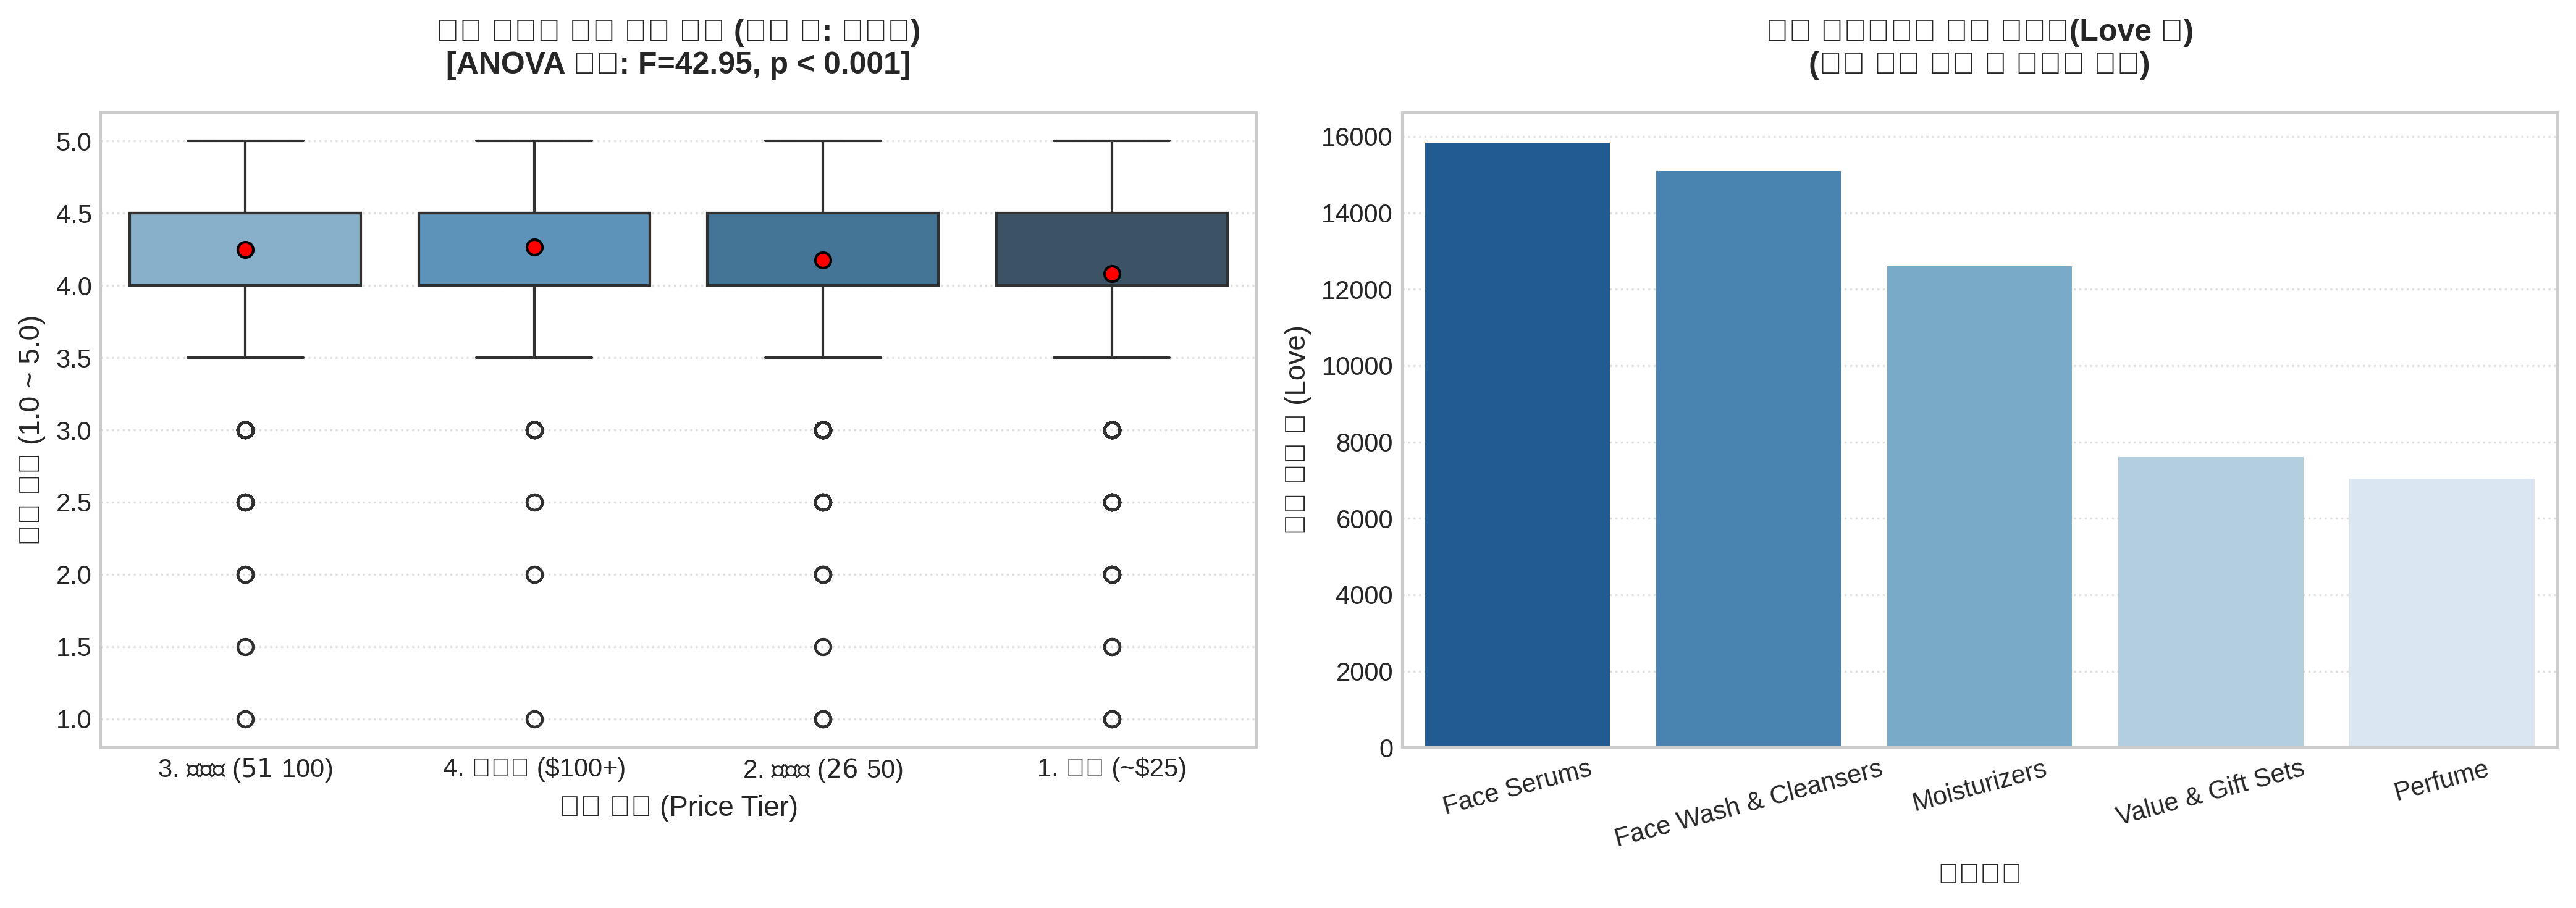

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [29]:
import koreanize_matplotlib
import matplotlib.pyplot as plt
import seaborn as sns
from google.colab import files

# 전체 캔버스 생성 및 차트 그리기 (반드시 한 셀에서 동시 실행)
plt.style.use('seaborn-v0_8-whitegrid')
fig, axes = plt.subplots(1, 2, figsize=(14, 5), dpi=300, facecolor='white')

# 왼쪽 차트: 가격대별 평점 박스플롯
sns.boxplot(
    data=df_clean,
    x='price_tier',
    y='rating',
    palette='Blues_d',
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markeredgecolor': 'black',
        'markerfacecolor': 'red',
        'markersize': '6',
    },
    ax=axes[0],
)
axes[0].set_title(
    '가격 구간별 고객 평점 분포 (빨간 점: 평균값)\n[ANOVA 검정: F=42.95, p <'
    ' 0.001]',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('가격 구간 (Price Tier)', fontsize=11)
axes[0].set_ylabel('고객 평점 (1.0 ~ 5.0)', fontsize=11)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

# 오른쪽 차트: 상위 5개 카테고리별 평균 하트 수 막대그래프
top5_cats = df_clean['category'].value_counts().head(5).index
cat_data = (
    df_clean[df_clean['category'].isin(top5_cats)]
    .groupby('category')['love']
    .mean()
    .reset_index()
    .sort_values(by='love', ascending=False)
)

sns.barplot(data=cat_data, x='category', y='love', palette='Blues_r', ax=axes[1])
axes[1].set_title(
    '주요 카테고리별 평균 관심도(Love 수)\n(실제 고객 반응 및 바이럴 지표)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('카테고리', fontsize=11)
axes[1].set_ylabel('평균 하트 수 (Love)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()

# 파일 저장 후 화면 출력 및 자동 다운로드
fig.savefig(
    'sephora_analysis_charts.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()
files.download('sephora_analysis_charts.png')

In [27]:
# 오른쪽 도화지(axes[1])에 막대그래프 그리기
top5_cats = df_clean['category'].value_counts().head(5).index
cat_data = (
    df_clean[df_clean['category'].isin(top5_cats)]
    .groupby('category')['love']
    .mean()
    .reset_index()
    .sort_values(by='love', ascending=False)
)

sns.barplot(data=cat_data, x='category', y='love', palette='Blues_r', ax=axes[1])
axes[1].set_title(
    '주요 카테고리별 평균 관심도(Love 수)\n(실제 고객 반응 및 바이럴 지표)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('카테고리', fontsize=11)
axes[1].set_ylabel('평균 하트 수 (Love)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()

/tmp/ipykernel_4109/1358506554.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_data, x='category', y='love', palette='Blues_r', ax=axes[1])


<Figure size 640x480 with 0 Axes>

In [28]:
# 이미지 저장 후 다운로드
fig.savefig(
    'sephora_analysis_charts.png',
    dpi=300,
    bbox_inches='tight',
    facecolor='white',
)
plt.show()
files.download('sephora_analysis_charts.png')

/tmp/ipykernel_4109/2887096218.py:2: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Liberation Sans.
  fig.savefig(
/tmp/ipykernel_4109/2887096218.py:2: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) Liberation Sans.
  fig.savefig(
/tmp/ipykernel_4109/2887096218.py:2: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Liberation Sans.
  fig.savefig(
/tmp/ipykernel_4109/2887096218.py:2: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) Liberation Sans.
  fig.savefig(
/tmp/ipykernel_4109/2887096218.py:2: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Liberation Sans.
  fig.savefig(
/tmp/ipykernel_4109/2887096218.py:2: UserWarning: Glyph 44201 (\N{HANGUL SYLLABLE GYEOG}) missing from font(s) Liberation Sans.
  fig.savefig(
/tmp/ipykernel_4109/2887096218.py:2: UserWarning: Glyph 44396 (\N{HANGUL SYLLABLE GU}) missing from font(s) Liberation Sans.
  fig.savefig(
/tmp/ipyk

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [21]:
# 왼쪽 차트: 가격 구간별 고객 평점 분포 (Boxplot)
sns.boxplot(
    data=df_clean,
    x='price_tier',
    y='rating',
    palette='Blues_d',
    showmeans=True,
    meanprops={
        'marker': 'o',
        'markeredgecolor': 'black',
        'markerfacecolor': 'red',
        'markersize': '6',
    },
    ax=axes[0],
)
axes[0].set_title(
    '가격 구간별 고객 평점 분포 (빨간 점: 평균값)\n[ANOVA 검정: F=42.95, p <'
    ' 0.001]',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[0].set_xlabel('가격 구간 (Price Tier)', fontsize=11)
axes[0].set_ylabel('고객 평점 (1.0 ~ 5.0)', fontsize=11)
axes[0].grid(axis='y', linestyle=':', alpha=0.6)

/tmp/ipykernel_4109/1965935314.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(


In [23]:
# 오른쪽 차트: 상위 5개 카테고리별 평균 하트 수 (Barplot)
top5_cats = df_clean['category'].value_counts().head(5).index
cat_data = (
    df_clean[df_clean['category'].isin(top5_cats)]
    .groupby('category')['love']
    .mean()
    .reset_index()
    .sort_values(by='love', ascending=False)
)

sns.barplot(data=cat_data, x='category', y='love', palette='Blues_r', ax=axes[1])
axes[1].set_title(
    '주요 카테고리별 평균 관심도(Love 수)\n(실제 고객 반응 및 바이럴 지표)',
    fontsize=12,
    fontweight='bold',
    pad=15,
)
axes[1].set_xlabel('카테고리', fontsize=11)
axes[1].set_ylabel('평균 하트 수 (Love)', fontsize=11)
axes[1].tick_params(axis='x', rotation=15)
axes[1].grid(axis='y', linestyle=':', alpha=0.6)

plt.tight_layout()

/tmp/ipykernel_4109/2760026410.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=cat_data, x='category', y='love', palette='Blues_r', ax=axes[1])


<Figure size 640x480 with 0 Axes>

In [24]:
# 화면에 띄우기 '전'에 먼저 이미지로 저장 (fig 사용)
fig.savefig('sephora_analysis_charts.png', dpi=300, bbox_inches='tight', facecolor='white')

# 코랩 화면에 그래프 출력
plt.show()

# 저장된 PNG 파일을 컴퓨터로 다운로드
files.download('sephora_analysis_charts.png')

/tmp/ipykernel_4109/8877055.py:2: UserWarning: Glyph 44256 (\N{HANGUL SYLLABLE GO}) missing from font(s) Liberation Sans.
  fig.savefig('sephora_analysis_charts.png', dpi=300, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_4109/8877055.py:2: UserWarning: Glyph 44061 (\N{HANGUL SYLLABLE GAEG}) missing from font(s) Liberation Sans.
  fig.savefig('sephora_analysis_charts.png', dpi=300, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_4109/8877055.py:2: UserWarning: Glyph 54217 (\N{HANGUL SYLLABLE PYEONG}) missing from font(s) Liberation Sans.
  fig.savefig('sephora_analysis_charts.png', dpi=300, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_4109/8877055.py:2: UserWarning: Glyph 51216 (\N{HANGUL SYLLABLE JEOM}) missing from font(s) Liberation Sans.
  fig.savefig('sephora_analysis_charts.png', dpi=300, bbox_inches='tight', facecolor='white')
/tmp/ipykernel_4109/8877055.py:2: UserWarning: Glyph 44032 (\N{HANGUL SYLLABLE GA}) missing from font(s) Liberation Sans.
  fig.

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>